In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
import matplotlib.colors as mcolors

In [2]:
data = Path("/home/py/groundwater/data/bow_valley/")

In [3]:
def read_gown(path):
    df = pd.read_csv(path, skiprows=9, sep=";")
    df.rename(columns={"#Timestamp": "Date"}, inplace=True)
    df["Date"] = pd.to_datetime(df["Date"]).dt.strftime("%Y-%m-%d")
    df.set_index("Date", inplace=True)
    df.index = pd.to_datetime(df.index)
    df = df.resample("D").mean()
    df = df.rename(columns={'Absolute Value': 'Elevation'})
    return df

In [4]:
berm = pd.read_csv(data / 'bighorn' / 'berm_combined.csv', parse_dates=[0], index_col=0)
berm = berm[~berm.index.duplicated(keep="first")]

brab = pd.read_csv(data / 'stream' / 'brab_elevation.csv', parse_dates=[0], index_col=0)

ex = read_gown(data / 'gown' / 'ex.csv')
ct = read_gown(data / 'gown' / 'ct.csv')

In [5]:
combined = pd.concat([berm['Elevation'].rename('Berm'),
                      ex['Elevation'].loc['2014':].rename('Exshaw'),
                      ct['Elevation'].loc['2014':].rename('Canmore Tourist'),
                      brab.loc['2014':]['Elevation'].rename('BRatB')],
                    axis=1)

In [6]:
combined

,Berm,Exshaw,Canmore Tourist,BRatB
Date,,,,
2014-01-01,NaN,1288.912042,1311.403333,1378.239
2014-01-02,NaN,1288.880292,1311.405917,1378.234
2014-01-03,NaN,1288.939875,1311.403042,1378.236
2014-01-04,NaN,1288.915000,1311.402042,1378.224
2014-01-05,NaN,1288.831042,1311.401208,1378.169
...,...,...,...,...
2026-07-26,NaN,NaN,1312.781042,NaN
2026-07-27,NaN,NaN,1312.768292,NaN
2026-07-28,NaN,NaN,1312.755083,NaN


In [7]:
def cross_plot(well):
    # plot_df = combined.copy().dropna()
    plot_df = combined.copy()
    plot_df["month"] = plot_df.index.month
    plot_df["year"] = plot_df.index.year

    before_2019 = plot_df["year"] < 2019
    after_2019 = plot_df["year"] >= 2019

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8), sharey=True)

    sc1 = ax1.scatter(
        plot_df.loc[before_2019, "BRatB"],
        plot_df.loc[before_2019, well],
        c=plot_df.loc[before_2019, "year"],
        cmap="Blues",
        norm=mcolors.Normalize(vmin=2014, vmax=2018),
        s=75, alpha=0.75, edgecolor="none"
    )
    ax1.set_title(f"2014-2018", fontsize=14, fontweight="bold")
    ax1.set_xlabel("Bow River @ Banff Water Level (m)", fontsize=14)
    ax1.set_ylabel(f"{well} GW Elevation (m)", fontsize=14)
    ax1.tick_params(axis='x', rotation=45)
    fig.colorbar(sc1, ax=ax1, label="Year")
    ax1.grid(alpha=0.75)

    sc2 = ax2.scatter(
        plot_df.loc[after_2019, "BRatB"],
        plot_df.loc[after_2019, well],
        c=plot_df.loc[after_2019, "year"],
        cmap="viridis",
        norm=mcolors.Normalize(vmin=2019, vmax=2026),
        s=75, alpha=0.75, edgecolor="none"
    )
    ax2.set_title(f"2019-2026", fontsize=14, fontweight="bold")
    ax2.set_xlabel("Bow River @ Banff Water Level (m)", fontsize=14)
    ax2.tick_params(axis='x', rotation=45)
    fig.colorbar(sc2, ax=ax2, label="Year")
    ax2.grid(alpha=0.75)

    fig.suptitle(f"Bow River @ Banff Stage vs {well} WL (daily values), coloured by year",
                fontsize=16, fontweight="bold")
    plt.tight_layout()
    plt.show()

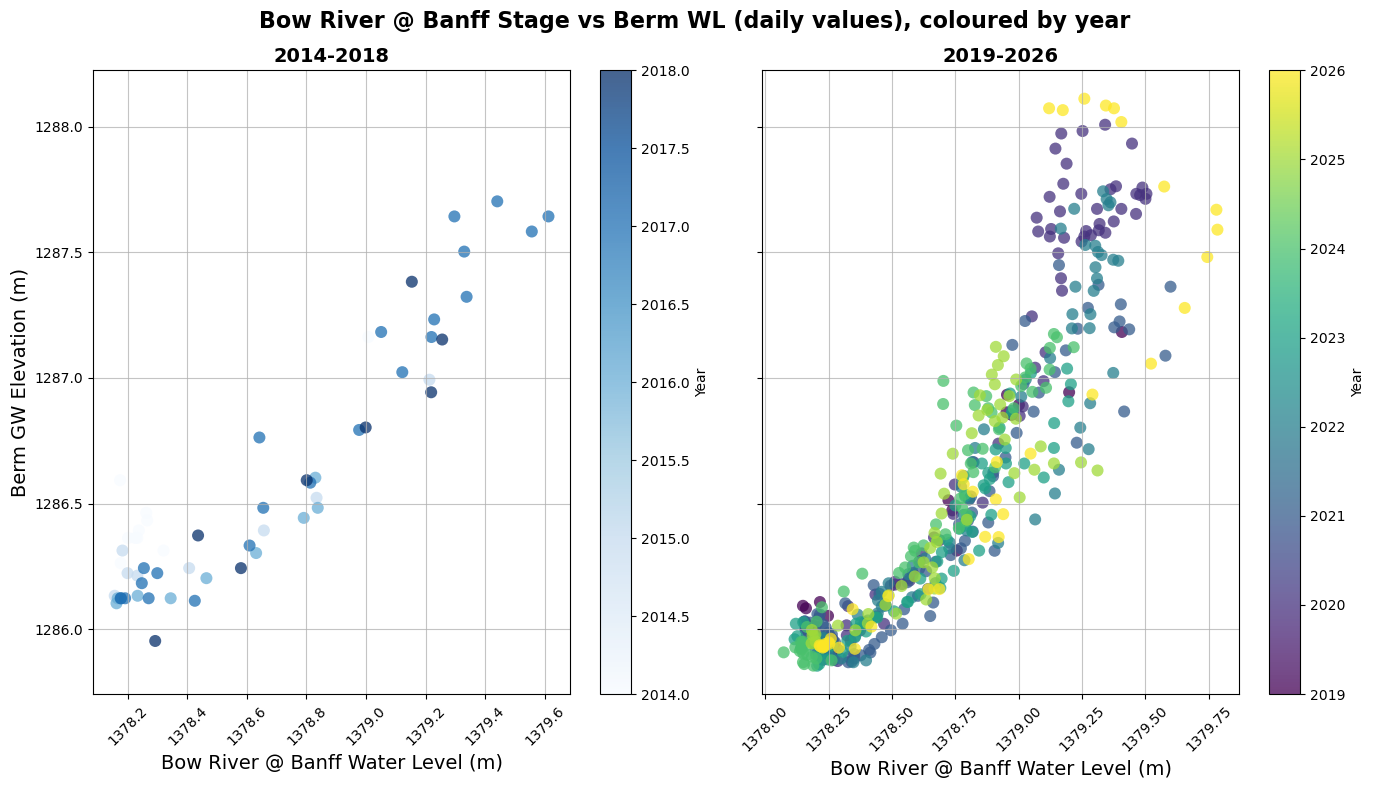

In [8]:
cross_plot('Berm')

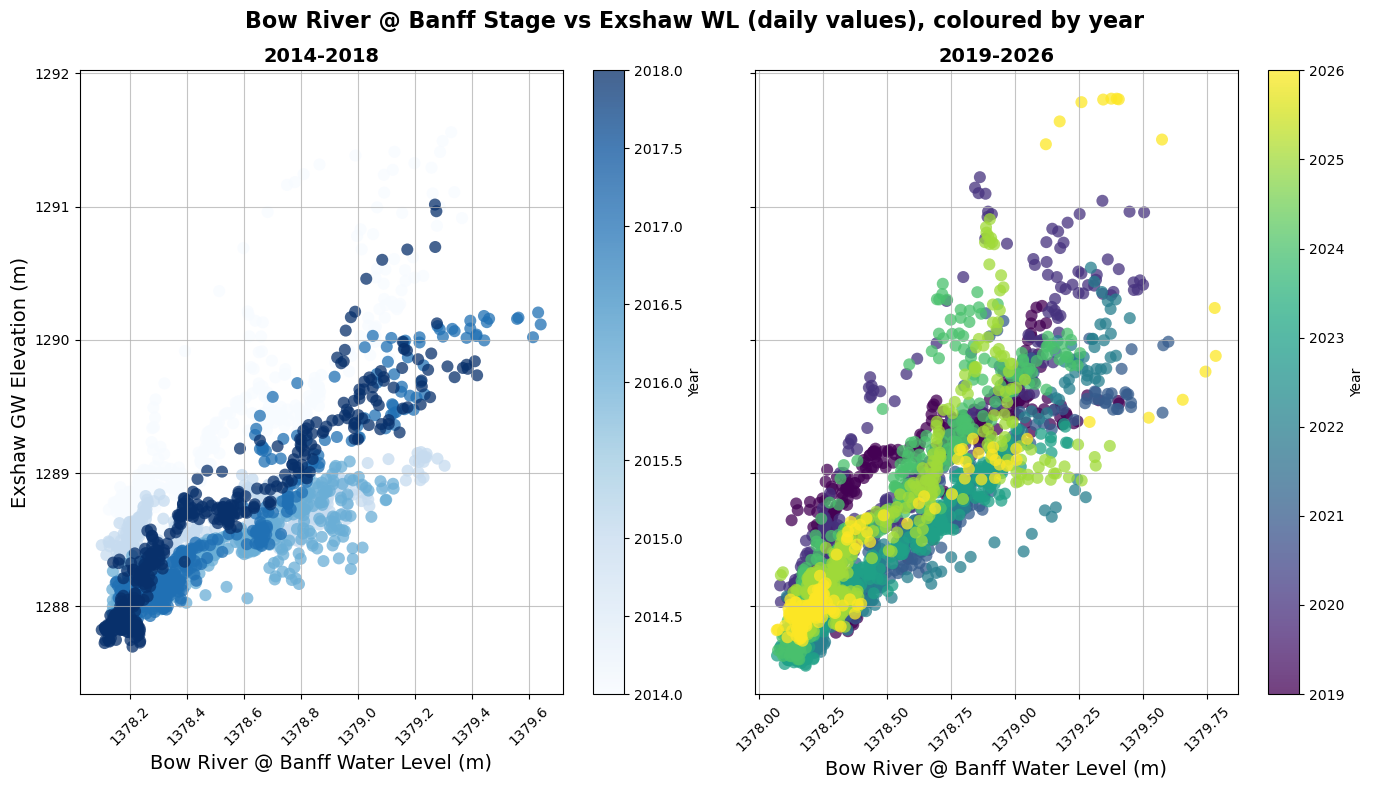

In [9]:
cross_plot('Exshaw')

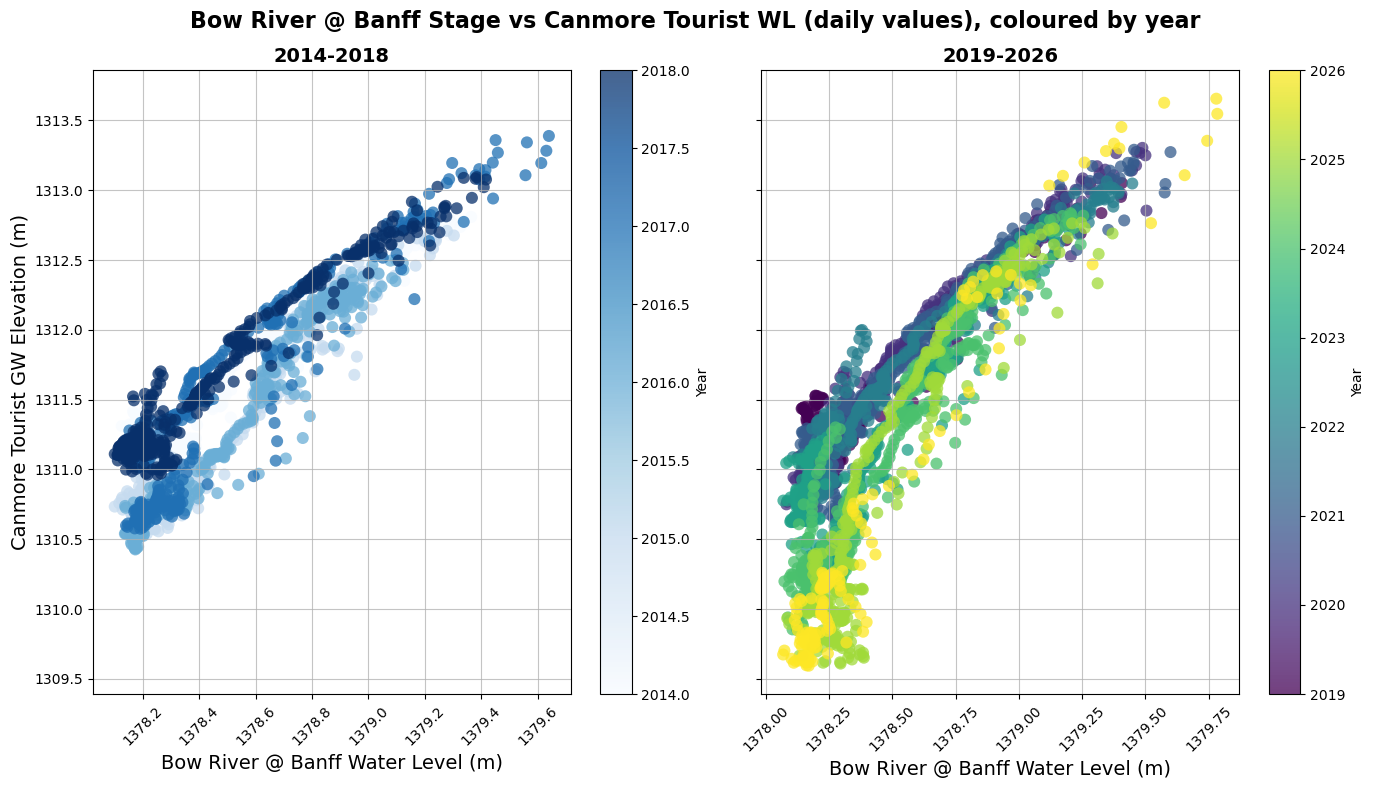

In [10]:
cross_plot('Canmore Tourist')

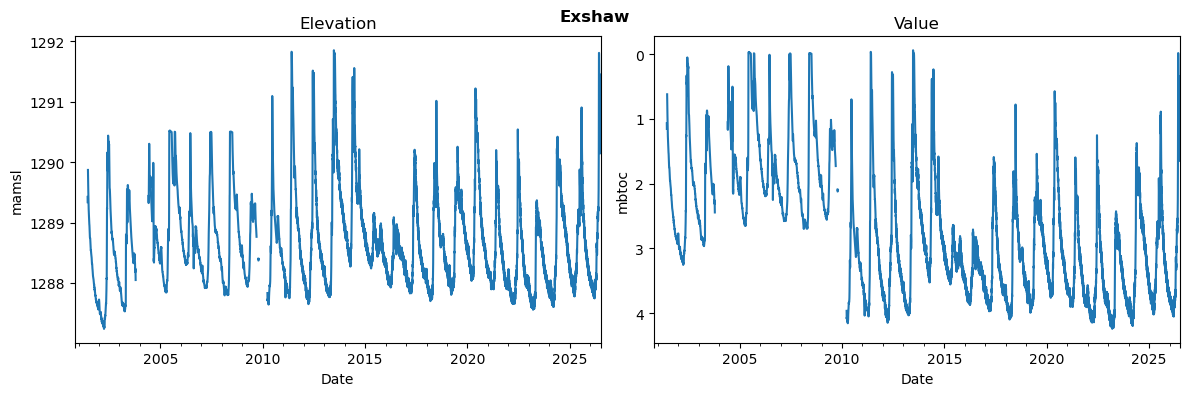

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(12,4))
ex['Elevation'].plot(ax=axs[0])
ex['Value'].plot(ax=axs[1])
axs[1].invert_yaxis()

axs[0].set_title('Elevation')
axs[0].set_ylabel('mamsl')

axs[1].set_title('Value')
axs[1].set_ylabel('mbtoc')

plt.tight_layout()
fig.suptitle("Exshaw", fontweight='bold')
plt.show()

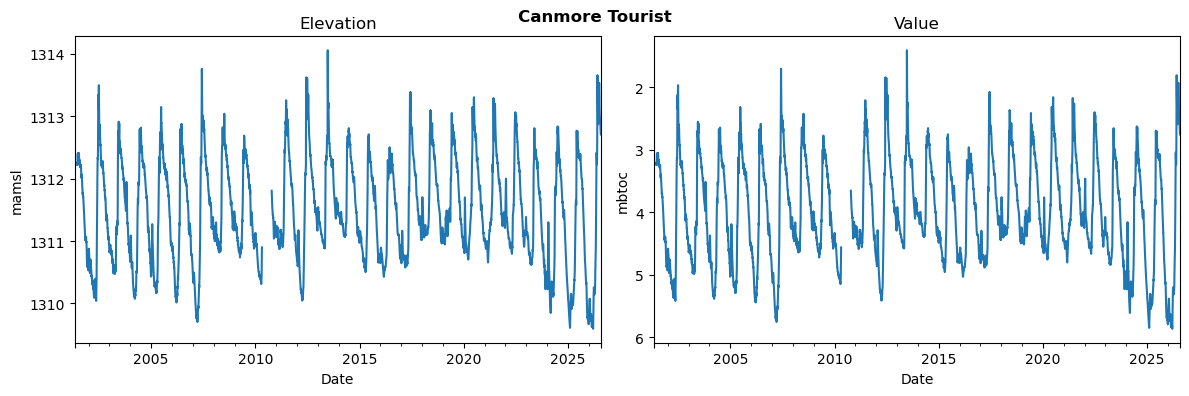

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(12,4))
ct['Elevation'].plot(ax=axs[0])
ct['Value'].plot(ax=axs[1])
axs[1].invert_yaxis()

axs[0].set_title('Elevation')
axs[0].set_ylabel('mamsl')

axs[1].set_title('Value')
axs[1].set_ylabel('mbtoc')

plt.tight_layout()
fig.suptitle("Canmore Tourist", fontweight='bold')
plt.show()

<Axes: xlabel='Date'>

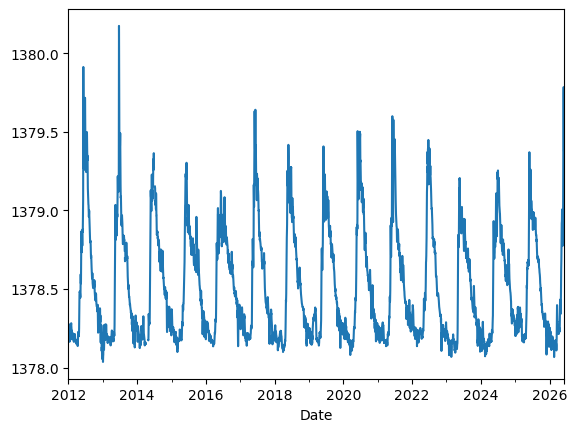

In [13]:
brab['Elevation'].plot()

In [14]:
berm_m = berm.resample('MS').mean().squeeze()
brab_m = brab['Elevation'].resample('MS').mean().squeeze()
ex_m = ex['Elevation'].resample('MS').mean().squeeze()
ct_m = ct['Elevation'].resample('MS').mean().squeeze()

M = pd.DataFrame({'berm': berm_m, 'ex': ex_m, 'ct': ct_m, 'brab': brab_m})
M = M.loc['2014':]

In [15]:
M

,berm,ex,ct,brab
Date,,,,
2014-01-01,1286.388000,1288.843294,1311.376467,1378.208129
2014-02-01,1286.473000,1288.712281,1311.360379,1378.211607
2014-03-01,1286.288000,1288.495060,1311.209763,1378.212935
2014-04-01,1286.258000,1288.461397,1311.087491,1378.177000
2014-05-01,1287.163000,1290.188078,1311.709684,1378.612258
...,...,...,...,...
2026-03-01,1285.924066,1287.886478,1309.802196,1378.222032
2026-04-01,1285.955814,1288.210518,1310.307311,1378.278333
2026-05-01,1286.659954,1289.079644,1312.027110,1378.920774


In [16]:
season = M.groupby(M.index.month).transform('mean')
A = M - season # anomaly = departure from the seasonal norm
Z_A = A / A.std() # standardized anomaly, comparable across series

In [17]:
Z_M = (M - M.mean()) / M.std()

<Axes: xlabel='Date'>

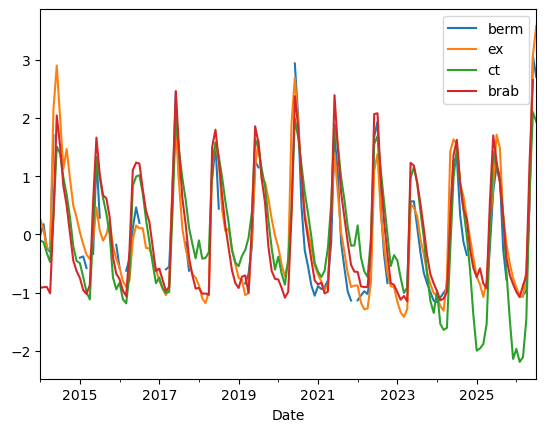

In [18]:
Z_M.plot()

<Axes: xlabel='Date'>

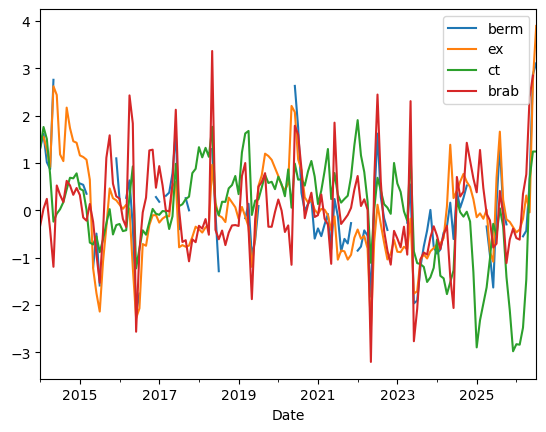

In [19]:
Z_A.plot()

In [20]:
before = M.index <= '2018-12-31'
after  = M.index >= '2019-01-01'

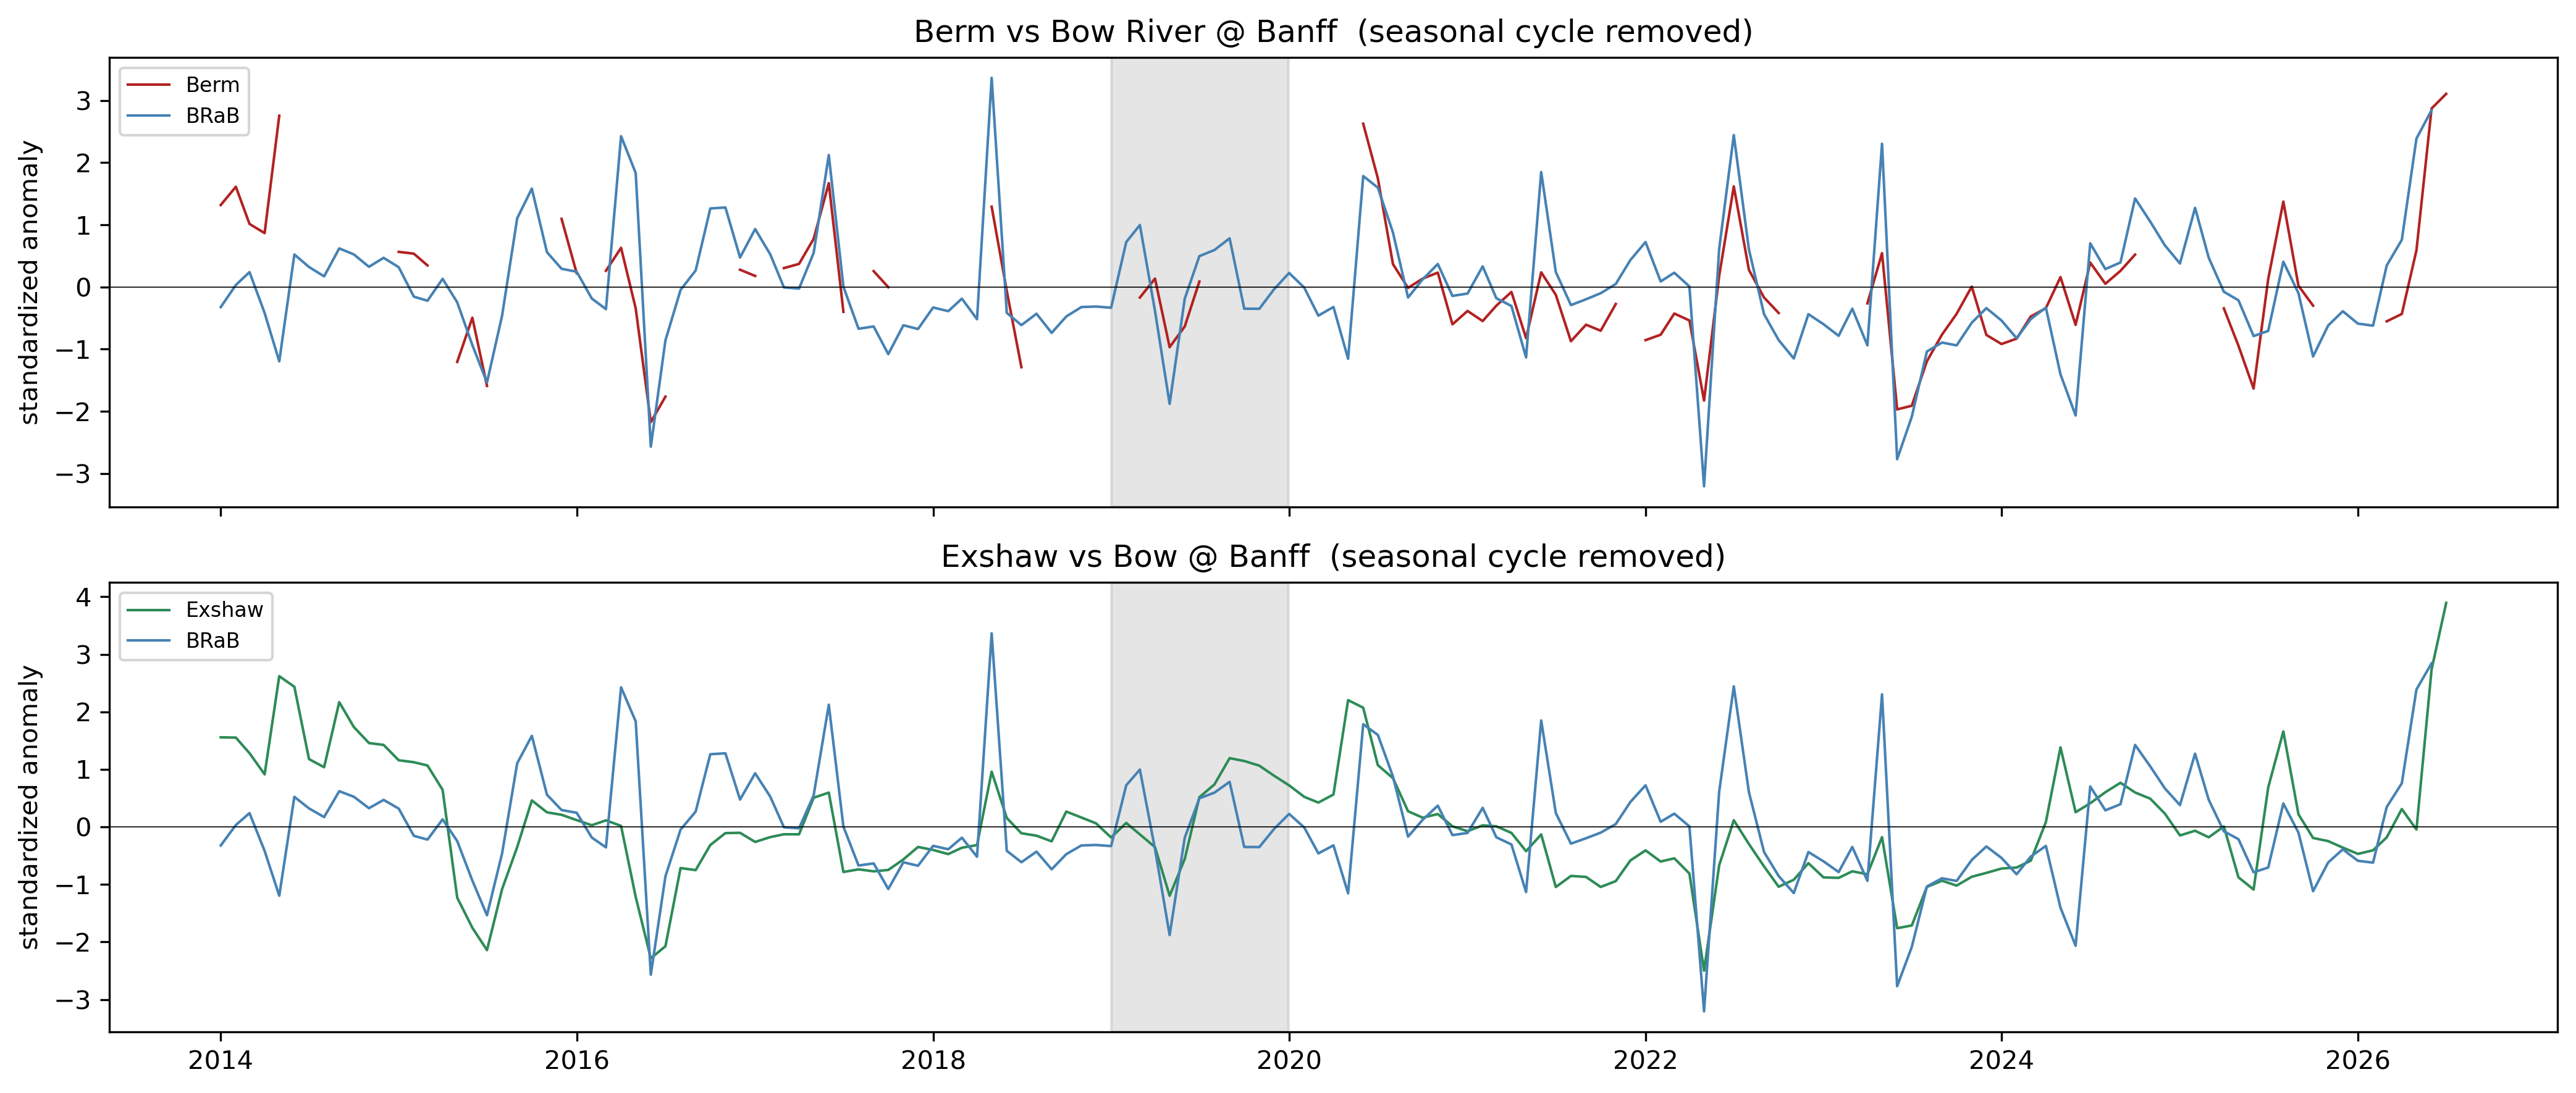

In [21]:
# does each well follow the Bow's freshet signal, and does the gap change after 2019?
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True, dpi=300)

ax1.plot(Z_A.index, Z_A['berm'], color='firebrick', lw=1, label='Berm')
ax1.plot(Z_A.index, Z_A['brab'], color='steelblue', lw=1, label='BRaB')
ax1.set_title('Berm vs Bow River @ Banff  (seasonal cycle removed)')

ax2.plot(Z_A.index, Z_A['ex'],   color='seagreen', lw=1, label='Exshaw')
ax2.plot(Z_A.index, Z_A['brab'], color='steelblue', lw=1, label='BRaB')
ax2.set_title('Exshaw vs Bow @ Banff  (seasonal cycle removed)')

for ax in (ax1, ax2):
    ax.axvspan(pd.Timestamp('2019-01-01'), pd.Timestamp('2019-12-31'), color='grey', alpha=.2)
    ax.axhline(0, color='k', lw=.4)
    ax.set_ylabel('standardized anomaly'); ax.legend(loc='upper left', fontsize=8)

plt.tight_layout()

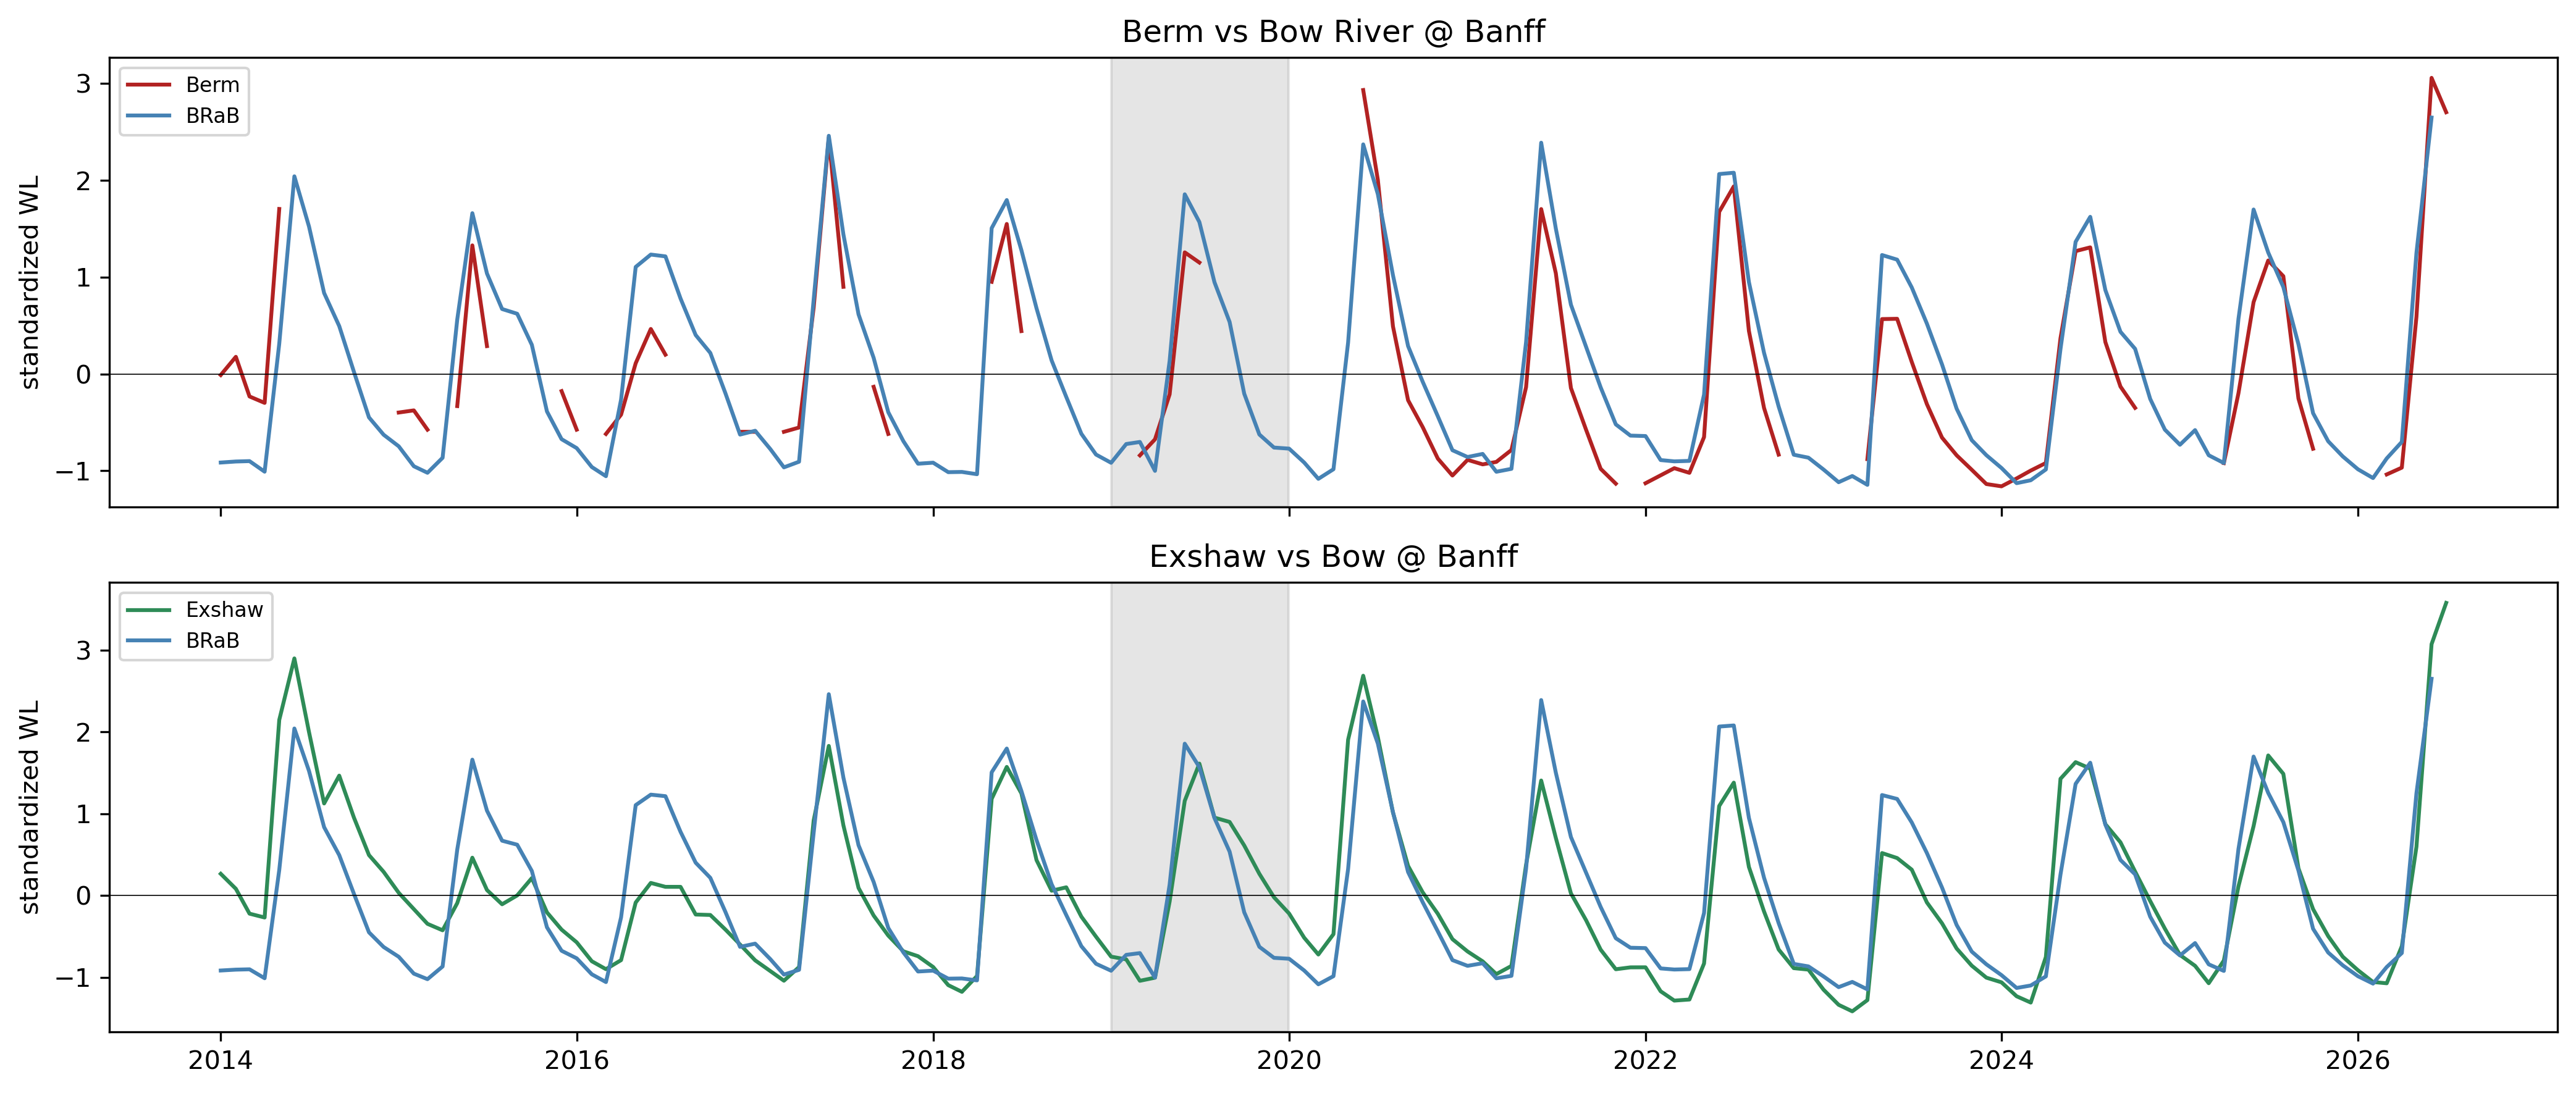

In [22]:
# does each well follow the Bow's freshet signal, and does the gap change after 2019?
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True, dpi=300)

ax1.plot(Z_M.index, Z_M['berm'], color='firebrick', lw=1.5, label='Berm')
ax1.plot(Z_M.index, Z_M['brab'], color='steelblue', lw=1.5, label='BRaB')
ax1.set_title('Berm vs Bow River @ Banff')

ax2.plot(Z_M.index, Z_M['ex'],   color='seagreen', lw=1.5, label='Exshaw')
ax2.plot(Z_M.index, Z_M['brab'], color='steelblue', lw=1.5, label='BRaB')
ax2.set_title('Exshaw vs Bow @ Banff')

for ax in (ax1, ax2):
    ax.axvspan(pd.Timestamp('2019-01-01'), pd.Timestamp('2019-12-31'), color='grey', alpha=.2)
    ax.axhline(0, color='k', lw=.4)
    ax.set_ylabel('standardized WL'); ax.legend(loc='upper left', fontsize=8)

plt.tight_layout()

In [23]:
def cross_plot_polyfit(well):
    plot_df = combined.copy()
    plot_df["month"] = plot_df.index.month
    plot_df["year"] = plot_df.index.year

    before_2019 = plot_df["year"] < 2019
    after_2019 = plot_df["year"] >= 2019

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8), sharey=True)

    sc1 = ax1.scatter(
        plot_df.loc[before_2019, "BRatB"],
        plot_df.loc[before_2019, well],
        c=plot_df.loc[before_2019, "year"],
        cmap="Blues",
        norm=mcolors.Normalize(vmin=2014, vmax=2018),
        s=75, alpha=0.75, edgecolor="none"
    )

    fit_df = plot_df.loc[before_2019, ["BRatB", well]].dropna()
    slope, intercept = np.polyfit(fit_df["BRatB"], fit_df[well], 1)
    xs = np.linspace(fit_df["BRatB"].min(), fit_df["BRatB"].max(), 20)
    ax1.plot(xs, intercept + slope * xs, color="black", lw=2, label=f"slope = {slope:+.2f}")
    ax1.legend(fontsize=10)

    ax1.set_title(f"2014-2018", fontsize=14, fontweight="bold")
    ax1.set_xlabel("Bow River @ Banff Water Level (m)", fontsize=14)
    ax1.set_ylabel(f"{well} GW Elevation (m)", fontsize=14)
    ax1.tick_params(axis='x', rotation=45)
    fig.colorbar(sc1, ax=ax1, label="Year")
    ax1.grid(alpha=0.75)

    sc2 = ax2.scatter(
        plot_df.loc[after_2019, "BRatB"],
        plot_df.loc[after_2019, well],
        c=plot_df.loc[after_2019, "year"],
        cmap="viridis",
        norm=mcolors.Normalize(vmin=2019, vmax=2026),
        s=75, alpha=0.75, edgecolor="none"
    )

    fit_df = plot_df.loc[after_2019, ["BRatB", well]].dropna()
    slope, intercept = np.polyfit(fit_df["BRatB"], fit_df[well], 1)
    xs = np.linspace(fit_df["BRatB"].min(), fit_df["BRatB"].max(), 20)
    ax2.plot(xs, intercept + slope * xs, color="black", lw=2, label=f"slope = {slope:+.2f}")
    ax2.legend(fontsize=10)

    ax2.set_title(f"2019-2026", fontsize=14, fontweight="bold")
    ax2.set_xlabel("Bow River @ Banff Water Level (m)", fontsize=14)
    ax2.tick_params(axis='x', rotation=45)
    fig.colorbar(sc2, ax=ax2, label="Year")
    ax2.grid(alpha=0.75)

    fig.suptitle(f"Bow River @ Banff Stage vs {well} WL (daily values), coloured by year",
                fontsize=16, fontweight="bold")
    plt.tight_layout()
    plt.show()

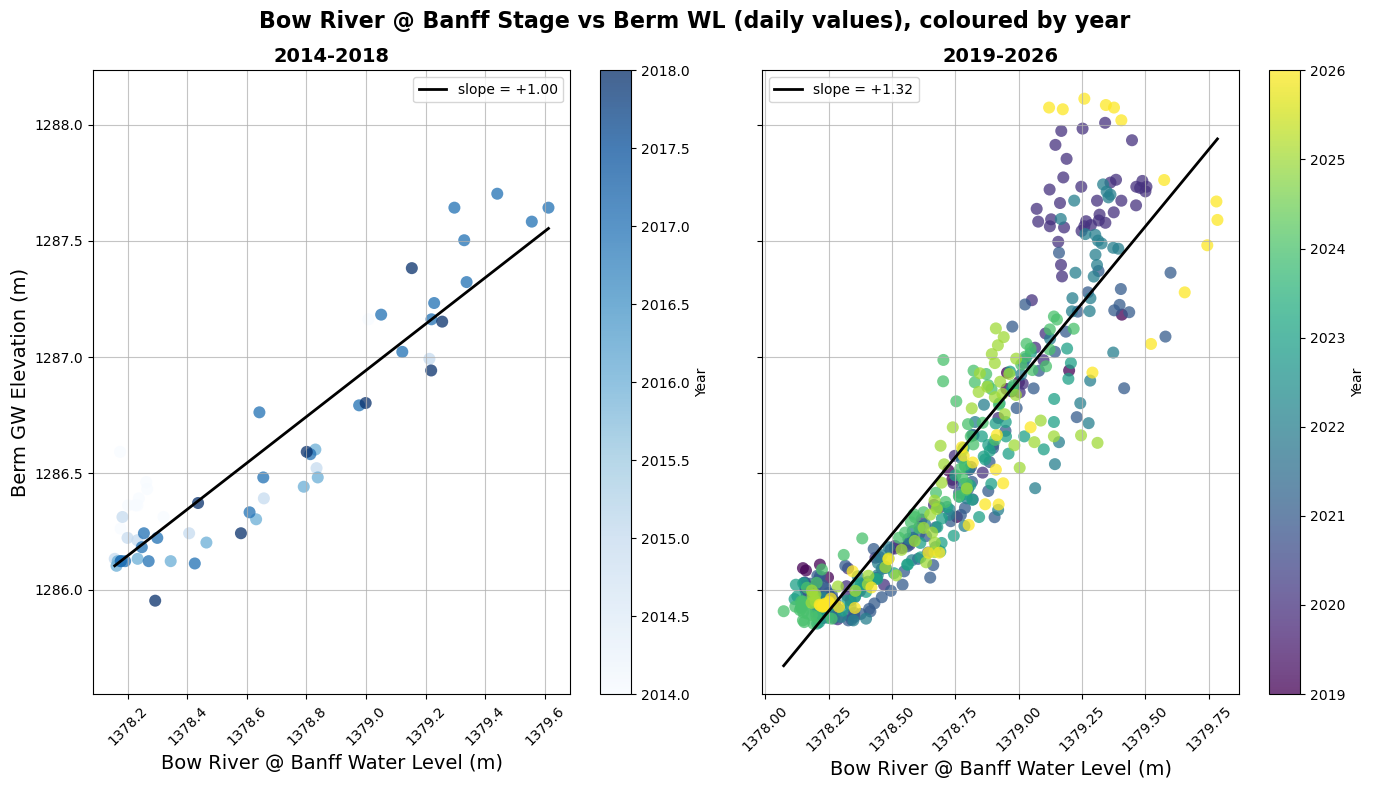

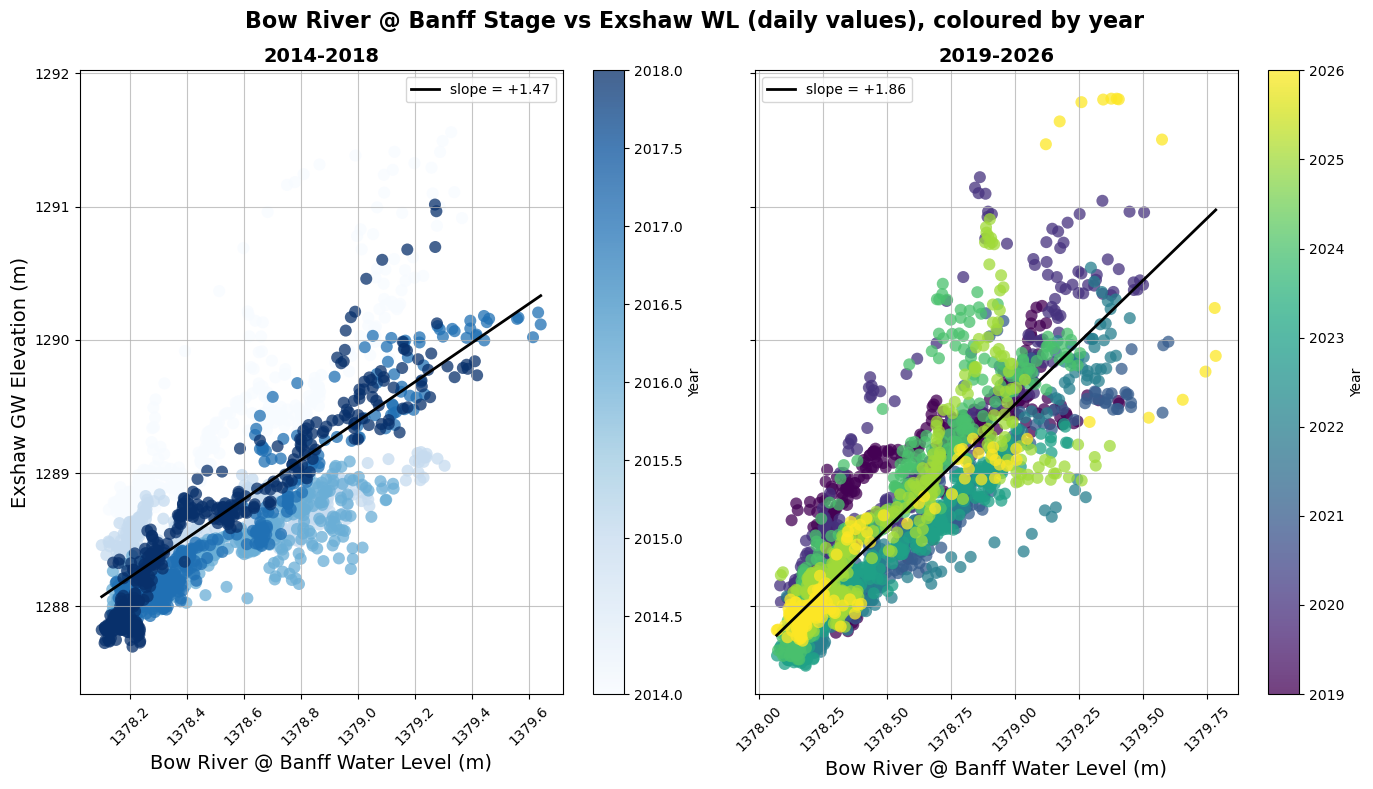

In [24]:
cross_plot_polyfit('Berm')
cross_plot_polyfit('Exshaw')

In [25]:
M

,berm,ex,ct,brab
Date,,,,
2014-01-01,1286.388000,1288.843294,1311.376467,1378.208129
2014-02-01,1286.473000,1288.712281,1311.360379,1378.211607
2014-03-01,1286.288000,1288.495060,1311.209763,1378.212935
2014-04-01,1286.258000,1288.461397,1311.087491,1378.177000
2014-05-01,1287.163000,1290.188078,1311.709684,1378.612258
...,...,...,...,...
2026-03-01,1285.924066,1287.886478,1309.802196,1378.222032
2026-04-01,1285.955814,1288.210518,1310.307311,1378.278333
2026-05-01,1286.659954,1289.079644,1312.027110,1378.920774


In [26]:
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [27]:
src = M
res = []

for y in range(2016, 2024):
    for well in ['berm','ex', 'ct']:
        d = src[[well,'brab']].dropna().copy()
        d['post'] = (d.index.year >= y).astype(int)

        m = smf.ols(f"{well} ~ brab * post", data=d).fit(cov_type='HAC', cov_kwds={'maxlags':6})
        b, (lo,hi) = m.params['brab:post'], m.conf_int().loc['brab:post']
        p = m.pvalues['brab:post']

        res.append({'year': y, 'well': well, 'slope_change': b, 'ci_lo': lo, 'ci_hi': hi, 'p': p})

res = pd.DataFrame(res)
res['p'] = res['p'].round(3)
res[res['well'].isin(['berm'])][['well', 'year', 'p']]
# res

,well,year,p
0,berm,2016,0.000
3,berm,2017,0.000
6,berm,2018,0.009
9,berm,2019,0.007
12,berm,2020,0.003
15,berm,2021,0.175
18,berm,2022,0.106
21,berm,2023,0.324


In [28]:
src = A
res = []

for y in range(2016, 2024):
    for well in ['berm','ex', 'ct']:
        d = src[[well,'brab']].dropna().copy()
        d['post'] = (d.index.year >= y).astype(int)

        m = smf.ols(f"{well} ~ brab * post", data=d).fit(cov_type='HAC', cov_kwds={'maxlags':6})
        b, (lo,hi) = m.params['brab:post'], m.conf_int().loc['brab:post']
        p = m.pvalues['brab:post']

        res.append({'year': y, 'well': well, 'slope_change': b, 'ci_lo': lo, 'ci_hi': hi, 'p': p})

res = pd.DataFrame(res)
# res[res['well'].isin(['berm', 'ex'])][['well', 'year', 'p']]
res

,year,well,slope_change,ci_lo,ci_hi,p
0,2016,berm,0.320675,-2.057123,2.698473,0.791529
1,2016,ex,-1.068219,-5.810603,3.674166,0.658865
2,2016,ct,0.478654,-1.039101,1.996409,0.536501
3,2017,berm,0.454243,-0.574273,1.482759,0.386701
4,2017,ex,0.249523,-1.990381,2.489426,0.827166
5,2017,ct,0.316072,-0.693827,1.325970,0.539601
6,2018,berm,0.408808,-0.481040,1.298655,0.367890
7,2018,ex,0.118526,-1.661418,1.898470,0.896160
8,2018,ct,0.685433,-0.406826,1.777693,0.218716
9,2019,berm,0.478647,-0.263543,1.220836,0.206229


Berm: Δslope=+0.436  SE=0.160  z=2.72  p=0.007
Exshaw: Δslope=+0.421  SE=0.294  z=1.43  p=0.153


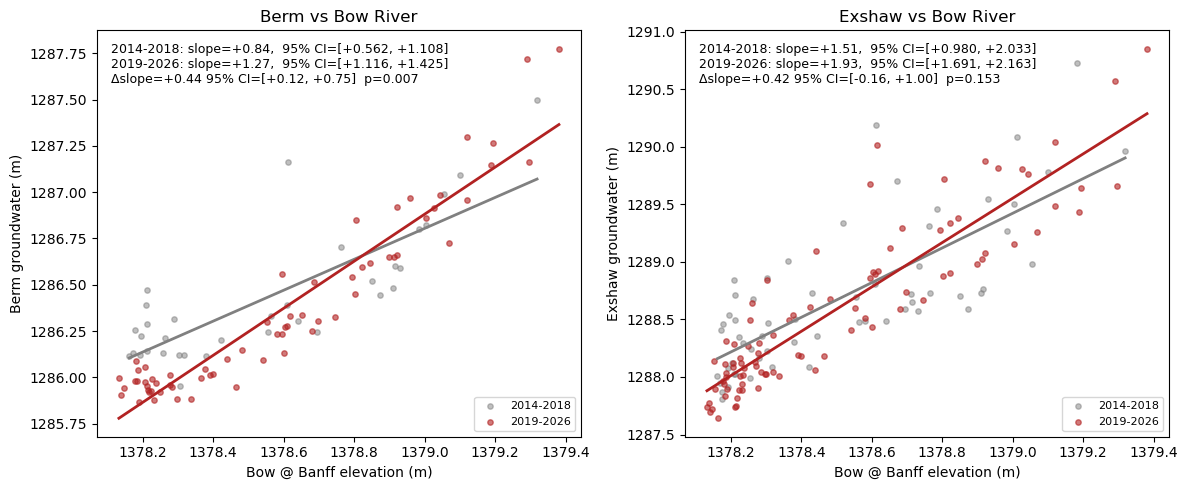

In [29]:
col_pre, col_post = 'grey', 'firebrick'      # 2014–2018, 2019–2026
titles = {'berm': 'Berm', 'ex': 'Exshaw'}

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

for ax, well in zip(axes, ['berm', 'ex']):
    pre  = M.loc[before, [well, 'brab']].dropna()
    post = M.loc[after,  [well, 'brab']].dropna()

    ax.scatter(pre['brab'],  pre[well],  s=15, alpha=.5, color=col_pre,  label='2014-2018')
    ax.scatter(post['brab'], post[well], s=15, alpha=.6, color=col_post, label='2019-2026')

    # fit each cloud with OLS so we get slope AND its 95% CI (polyfit gives only the slope)
    lines = []
    fits = {} # each period's slope and SE
    for data, colour, tag in [(pre, col_pre, '2014-2018'), (post, col_post, '2019-2026')]:
        X = sm.add_constant(data['brab'])
        res = sm.OLS(data[well], X).fit(cov_type='HAC', cov_kwds={'maxlags': 6})
        fits[tag] = (res.params['brab'], res.bse['brab']) # slope, std error

        lo, hi = res.conf_int().loc['brab'] # 95% CI on the slope
        xs = np.sort(data['brab'].values)
        ax.plot(xs, res.params['const'] + res.params['brab'] * xs, color=colour, lw=2)
        lines.append(f"{tag}: slope={res.params['brab']:+.2f},  95% CI=[{lo:+.3f}, {hi:+.3f}]")

    # significance of change
    (b_pre, se_pre), (b_post, se_post) = fits['2014-2018'], fits['2019-2026']
    diff = b_post - b_pre
    se_diff = np.sqrt(se_pre**2 + se_post**2) # variances add (disjoint periods -> independent)
    lo_d, hi_d = diff - 1.96*se_diff, diff + 1.96*se_diff
    z = diff / se_diff
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    lines.append(f"Δslope={diff:+.2f} 95% CI=[{lo_d:+.2f}, {hi_d:+.2f}]  p={p:.3f}")
    print(f"{titles[well]}: Δslope={diff:+.3f}  SE={se_diff:.3f}  z={z:.2f}  p={p:.3f}")


    # write the slopes + CIs directly on the panel
    ax.text(0.03, 0.97, "\n".join(lines), transform=ax.transAxes, va='top', ha='left',
        fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='none'))

    ax.set_xlabel('Bow @ Banff elevation (m)')
    ax.set_ylabel(f'{titles[well]} groundwater (m)')
    ax.set_title(f'{titles[well]} vs Bow River')
    ax.legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.show()

Berm: Δslope=+0.479  SE=0.377  z=1.27  p=0.204
Exshaw: Δslope=+0.324  SE=0.713  z=0.45  p=0.650


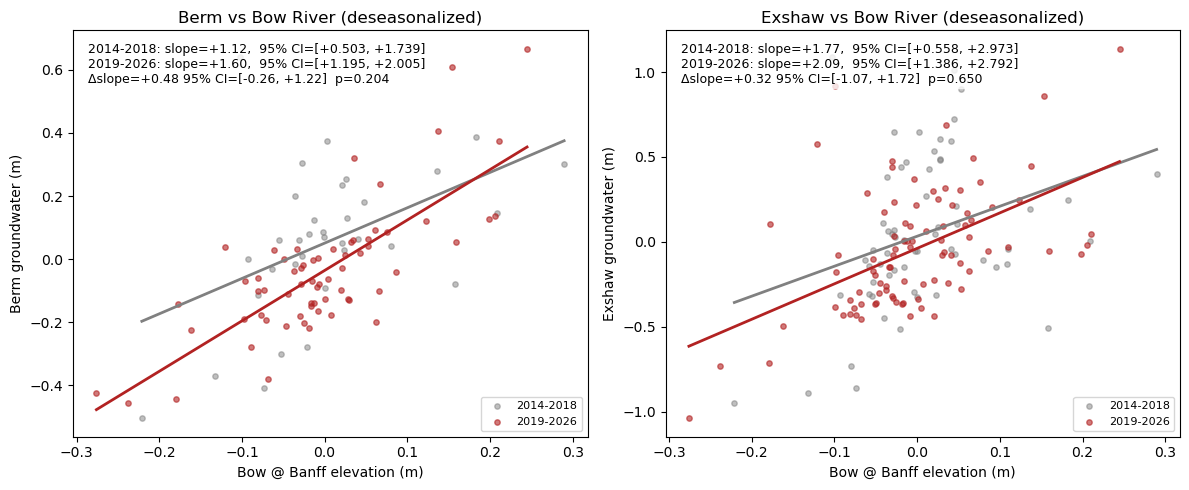

In [30]:
col_pre, col_post = 'grey', 'firebrick'      # 2014–2018, 2019–2026
titles = {'berm': 'Berm', 'ex': 'Exshaw'}

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

for ax, well in zip(axes, ['berm', 'ex']):
    pre  = A.loc[before, [well, 'brab']].dropna()
    post = A.loc[after,  [well, 'brab']].dropna()

    ax.scatter(pre['brab'],  pre[well],  s=15, alpha=.5, color=col_pre,  label='2014-2018')
    ax.scatter(post['brab'], post[well], s=15, alpha=.6, color=col_post, label='2019-2026')

    # fit each cloud with OLS so we get slope AND its 95% CI (polyfit gives only the slope)
    lines = []
    fits = {} # each period's slope and SE
    for data, colour, tag in [(pre, col_pre, '2014-2018'), (post, col_post, '2019-2026')]:
        X = sm.add_constant(data['brab'])
        res = sm.OLS(data[well], X).fit(cov_type='HAC', cov_kwds={'maxlags': 6})
        fits[tag] = (res.params['brab'], res.bse['brab']) # slope, std error

        lo, hi = res.conf_int().loc['brab'] # 95% CI on the slope
        xs = np.sort(data['brab'].values)
        ax.plot(xs, res.params['const'] + res.params['brab'] * xs, color=colour, lw=2)
        lines.append(f"{tag}: slope={res.params['brab']:+.2f},  95% CI=[{lo:+.3f}, {hi:+.3f}]")

    # significance of change
    (b_pre, se_pre), (b_post, se_post) = fits['2014-2018'], fits['2019-2026']
    diff = b_post - b_pre
    se_diff = np.sqrt(se_pre**2 + se_post**2) # variances add (disjoint periods -> independent)
    lo_d, hi_d = diff - 1.96*se_diff, diff + 1.96*se_diff
    z = diff / se_diff
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    lines.append(f"Δslope={diff:+.2f} 95% CI=[{lo_d:+.2f}, {hi_d:+.2f}]  p={p:.3f}")
    print(f"{titles[well]}: Δslope={diff:+.3f}  SE={se_diff:.3f}  z={z:.2f}  p={p:.3f}")


    # write the slopes + CIs directly on the panel
    ax.text(0.03, 0.97, "\n".join(lines), transform=ax.transAxes, va='top', ha='left',
        fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='none'))

    ax.set_xlabel('Bow @ Banff elevation (m)')
    ax.set_ylabel(f'{titles[well]} groundwater (m)')
    ax.set_title(f'{titles[well]} vs Bow River (deseasonalized)')
    ax.legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.show()

## Using one interaction model

Berm: Δslope=+0.436  95% CI [+0.118, +0.754]  p=0.007
Exshaw: Δslope=+0.421  95% CI [-0.156, +0.997]  p=0.153


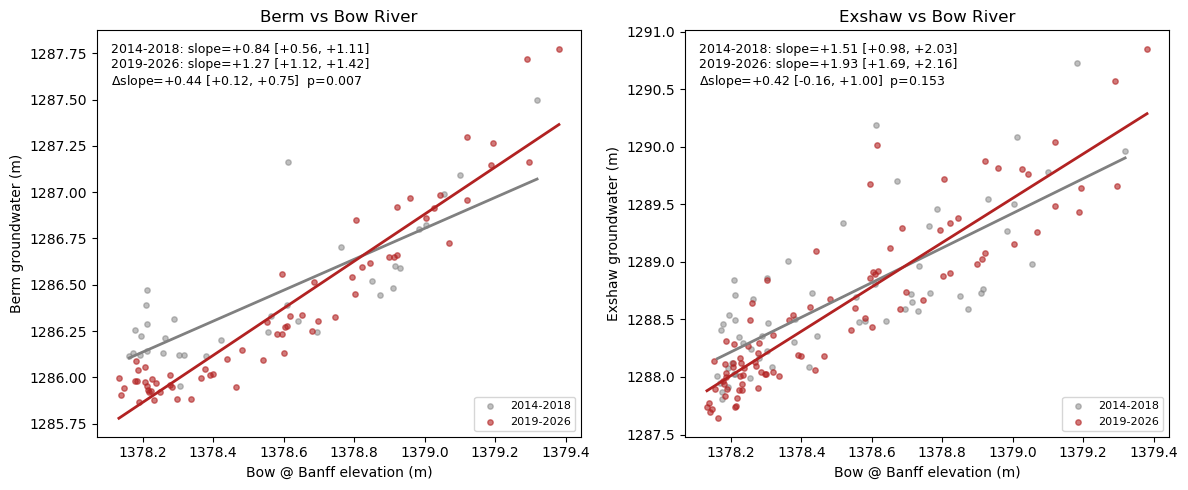

In [31]:
col_pre, col_post = 'grey', 'firebrick'      # 2014–2018, 2019–2026
titles = {'berm': 'Berm', 'ex': 'Exshaw'}

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

src = M

for ax, well in zip(axes, ['berm', 'ex']):
    pre  = src.loc[before, [well, 'brab']].dropna()
    post = src.loc[after,  [well, 'brab']].dropna()

    ax.scatter(pre['brab'],  pre[well],  s=15, alpha=.5, color=col_pre,  label='2014-2018')
    ax.scatter(post['brab'], post[well], s=15, alpha=.6, color=col_post, label='2019-2026')

    # draw each period's fitted line (per-period slopes, for the picture only)
    lines = []
    for data, colour, tag in [(pre, col_pre, '2014-2018'), (post, col_post, '2019-2026')]:
        r = sm.OLS(data[well], sm.add_constant(data['brab'])).fit(cov_type='HAC', cov_kwds={'maxlags': 6})
        lo, hi = r.conf_int().loc['brab']
        xs = np.sort(data['brab'].values)
        ax.plot(xs, r.params['const'] + r.params['brab'] * xs, color=colour, lw=2)
        lines.append(f"{tag}: slope={r.params['brab']:+.2f} [{lo:+.2f}, {hi:+.2f}]")

    # --- ONE interaction model gives the change in slope directly ---
    d = pd.concat([pre.assign(post=0), post.assign(post=1)])      # stack both periods, tag with post dummy
    m = smf.ols(f"{well} ~ brab * post", data=d).fit(cov_type='HAC', cov_kwds={'maxlags': 6})
    diff        = m.params['brab:post']                          # slope change = interaction coefficient
    lo_d, hi_d  = m.conf_int().loc['brab:post']                  # its 95% CI, from the model
    p           = m.pvalues['brab:post']                         # its p-value, from the model
    lines.append(f"$\\Delta$slope={diff:+.2f} [{lo_d:+.2f}, {hi_d:+.2f}]  p={p:.3f}")
    print(f"{titles[well]}: Δslope={diff:+.3f}  95% CI [{lo_d:+.3f}, {hi_d:+.3f}]  p={p:.3f}")

    ax.text(0.03, 0.97, "\n".join(lines), transform=ax.transAxes, va='top', ha='left',
            fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.85, edgecolor='none'))

    ax.set_xlabel('Bow @ Banff elevation (m)')
    ax.set_ylabel(f'{titles[well]} groundwater (m)')
    ax.set_title(f'{titles[well]} vs Bow River')
    ax.legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.show()

Berm: Δslope=+0.479  95% CI [-0.264, +1.221]  p=0.206
Exshaw: Δslope=+0.324  95% CI [-1.073, +1.720]  p=0.650


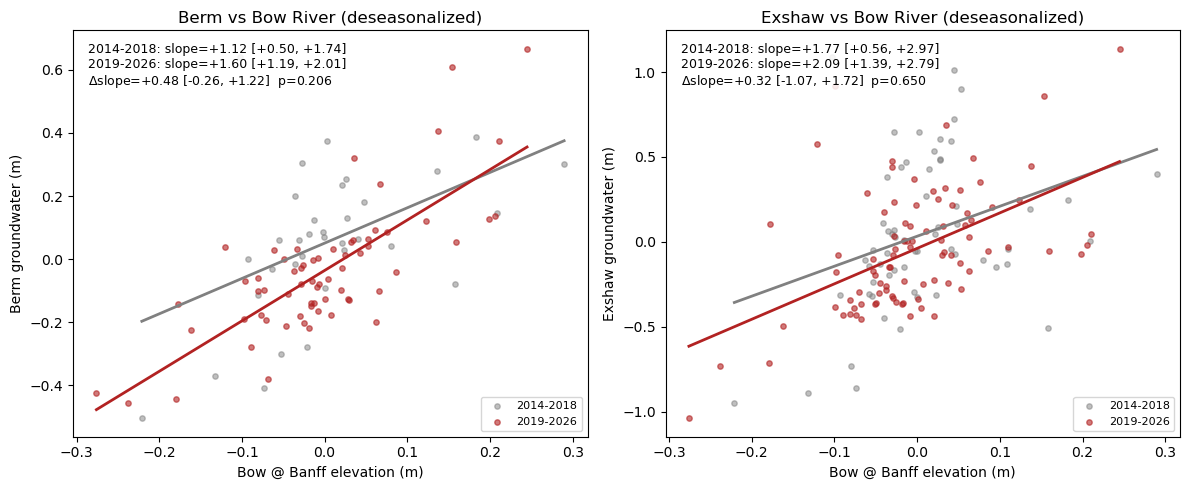

In [32]:
col_pre, col_post = 'grey', 'firebrick'      # 2014–2018, 2019–2026
titles = {'berm': 'Berm', 'ex': 'Exshaw'}

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

src = A

for ax, well in zip(axes, ['berm', 'ex']):
    pre  = src.loc[before, [well, 'brab']].dropna()
    post = src.loc[after,  [well, 'brab']].dropna()

    ax.scatter(pre['brab'],  pre[well],  s=15, alpha=.5, color=col_pre,  label='2014-2018')
    ax.scatter(post['brab'], post[well], s=15, alpha=.6, color=col_post, label='2019-2026')

    # draw each period's fitted line (per-period slopes, for the picture only)
    lines = []
    for data, colour, tag in [(pre, col_pre, '2014-2018'), (post, col_post, '2019-2026')]:
        r = sm.OLS(data[well], sm.add_constant(data['brab'])).fit(cov_type='HAC', cov_kwds={'maxlags': 6})
        lo, hi = r.conf_int().loc['brab']
        xs = np.sort(data['brab'].values)
        ax.plot(xs, r.params['const'] + r.params['brab'] * xs, color=colour, lw=2)
        lines.append(f"{tag}: slope={r.params['brab']:+.2f} [{lo:+.2f}, {hi:+.2f}]")

    # --- ONE interaction model gives the change in slope directly ---
    d = pd.concat([pre.assign(post=0), post.assign(post=1)])      # stack both periods, tag with post dummy
    m = smf.ols(f"{well} ~ brab * post", data=d).fit(cov_type='HAC', cov_kwds={'maxlags': 6})
    diff        = m.params['brab:post']                          # slope change = interaction coefficient
    lo_d, hi_d  = m.conf_int().loc['brab:post']                  # its 95% CI, from the model
    p           = m.pvalues['brab:post']                         # its p-value, from the model
    lines.append(f"$\\Delta$slope={diff:+.2f} [{lo_d:+.2f}, {hi_d:+.2f}]  p={p:.3f}")
    print(f"{titles[well]}: Δslope={diff:+.3f}  95% CI [{lo_d:+.3f}, {hi_d:+.3f}]  p={p:.3f}")

    ax.text(0.03, 0.97, "\n".join(lines), transform=ax.transAxes, va='top', ha='left',
            fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.85, edgecolor='none'))

    ax.set_xlabel('Bow @ Banff elevation (m)')
    ax.set_ylabel(f'{titles[well]} groundwater (m)')
    ax.set_title(f'{titles[well]} vs Bow River (deseasonalized)')
    ax.legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.show()

ct: Δslope=+0.342  95% CI [-0.075, +0.760]  p=0.108


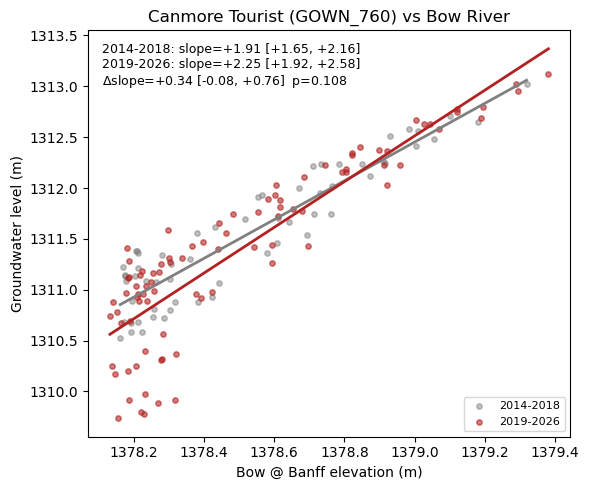

In [33]:
col_pre, col_post = 'grey', 'firebrick'      # 2014–2018, 2019–2026

fig, ax = plt.subplots(figsize=(6, 5))

src = M

pre  = src.loc[before, ['ct', 'brab']].dropna()
post = src.loc[after,  ['ct', 'brab']].dropna()

ax.scatter(pre['brab'],  pre['ct'],  s=15, alpha=.5, color=col_pre,  label='2014-2018')
ax.scatter(post['brab'], post['ct'], s=15, alpha=.6, color=col_post, label='2019-2026')

lines = []
for data, colour, tag in [(pre, col_pre, '2014-2018'), (post, col_post, '2019-2026')]:
    r = sm.OLS(data['ct'], sm.add_constant(data['brab'])).fit(cov_type='HAC', cov_kwds={'maxlags': 6})
    lo, hi = r.conf_int().loc['brab']
    xs = np.sort(data['brab'].values)
    ax.plot(xs, r.params['const'] + r.params['brab'] * xs, color=colour, lw=2)
    lines.append(f"{tag}: slope={r.params['brab']:+.2f} [{lo:+.2f}, {hi:+.2f}]")

# --- ONE interaction model gives the change in slope directly ---
d = pd.concat([pre.assign(post=0), post.assign(post=1)])      # stack both periods, tag with post dummy
m = smf.ols(f"ct ~ brab * post", data=d).fit(cov_type='HAC', cov_kwds={'maxlags': 6})
diff        = m.params['brab:post']                          # slope change = interaction coefficient
lo_d, hi_d  = m.conf_int().loc['brab:post']                  # its 95% CI, from the model
p           = m.pvalues['brab:post']                         # its p-value, from the model
lines.append(f"$\\Delta$slope={diff:+.2f} [{lo_d:+.2f}, {hi_d:+.2f}]  p={p:.3f}")
print(f"ct: Δslope={diff:+.3f}  95% CI [{lo_d:+.3f}, {hi_d:+.3f}]  p={p:.3f}")

ax.text(0.03, 0.97, "\n".join(lines), transform=ax.transAxes, va='top', ha='left',
        fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.85, edgecolor='none'))

ax.set_xlabel('Bow @ Banff elevation (m)')
ax.set_ylabel('Groundwater level (m)')
ax.set_title('Canmore Tourist (GOWN_760) vs Bow River')
ax.legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.show()

In [45]:
def cross_plot_m(well, year_split):
    plot_df = combined.resample('MS').mean().copy()
    plot_df["month"] = plot_df.index.month
    plot_df["year"] = plot_df.index.year

    before_2019 = plot_df["year"] < year_split
    after_2019 = plot_df["year"] >= year_split

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8), sharey=True)

    sc1 = ax1.scatter(
        plot_df.loc[before_2019, "BRatB"],
        plot_df.loc[before_2019, well],
        c=plot_df.loc[before_2019, "year"],
        cmap="Blues",
        norm=mcolors.Normalize(vmin=2014, vmax=year_split-1),
        s=75, alpha=0.75, edgecolor="none"
    )
    ax1.set_title(f"2014-{year_split-1}", fontsize=14, fontweight="bold")
    ax1.set_xlabel("Bow River @ Banff Water Level (m)", fontsize=14)
    ax1.set_ylabel(f"{well} GW Elevation (m)", fontsize=14)
    ax1.tick_params(axis='x', rotation=45)
    fig.colorbar(sc1, ax=ax1, label="Year")
    ax1.grid(alpha=0.75)

    sc2 = ax2.scatter(
        plot_df.loc[after_2019, "BRatB"],
        plot_df.loc[after_2019, well],
        c=plot_df.loc[after_2019, "year"],
        cmap="viridis",
        norm=mcolors.Normalize(vmin=year_split, vmax=2026),
        s=75, alpha=0.75, edgecolor="none"
    )
    ax2.set_title(f"{year_split}-2026", fontsize=14, fontweight="bold")
    ax2.set_xlabel("Bow River @ Banff Water Level (m)", fontsize=14)
    ax2.tick_params(axis='x', rotation=45)
    fig.colorbar(sc2, ax=ax2, label="Year")
    ax2.grid(alpha=0.75)

    fig.suptitle(f"Bow River @ Banff Stage vs {well} WL (daily values), coloured by year",
                fontsize=16, fontweight="bold")
    plt.tight_layout()
    plt.show()

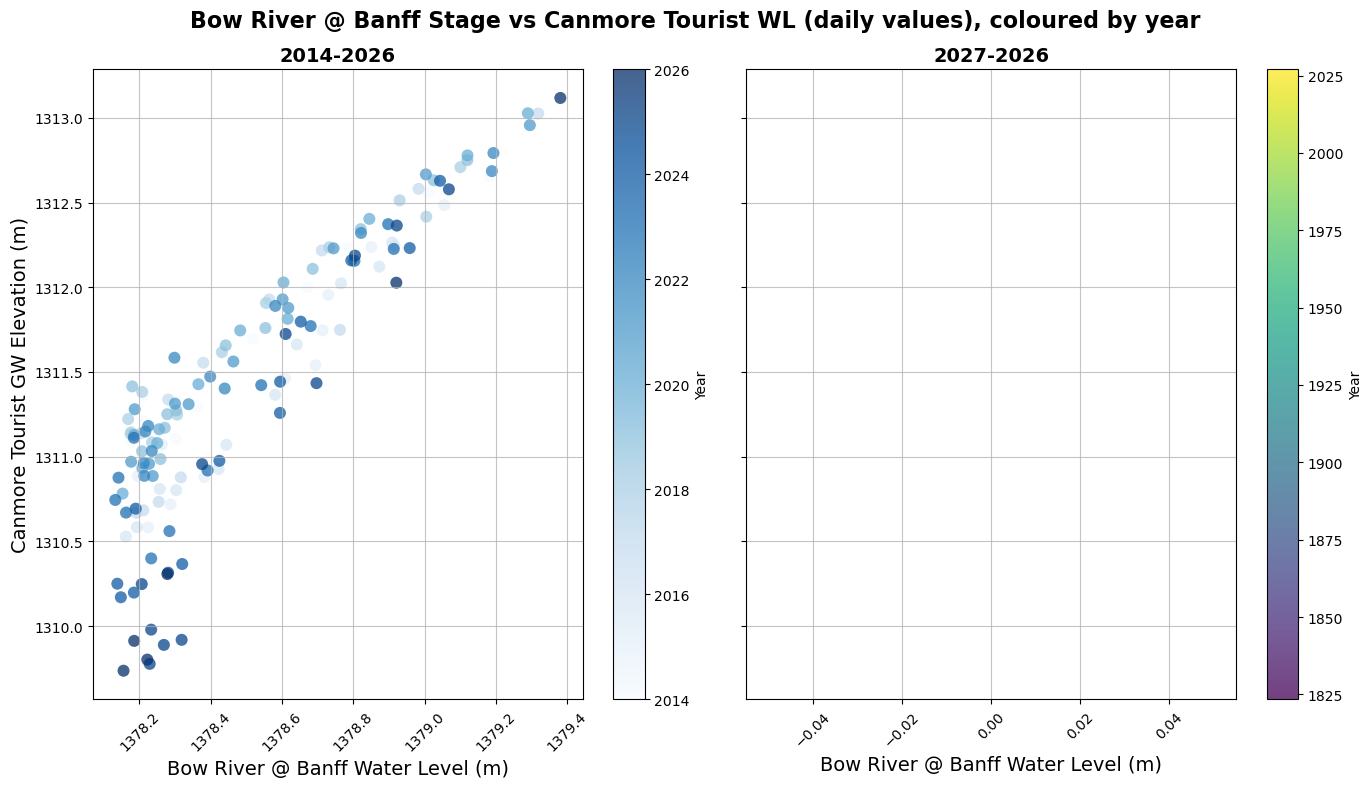

In [49]:
cross_plot_m('Canmore Tourist', 2027)

In [60]:
ct_m = combined['Canmore Tourist'].resample('MS').mean()
brab_m = combined['BRatB'].resample('MS').mean()

In [58]:
ct_m[ct_m.values < 1310.5]

Date
2023-12-01    1310.399577
2024-02-01    1310.250298
2024-03-01    1310.170266
2024-04-01    1310.197986
2024-12-01    1310.366527
2025-01-01    1309.889107
2025-02-01    1309.918980
2025-03-01    1309.979071
2025-04-01    1310.248120
2025-11-01    1310.315293
2025-12-01    1309.777099
2026-01-01    1309.912875
2026-02-01    1309.736682
2026-03-01    1309.802196
2026-04-01    1310.307311
Name: Canmore Tourist, dtype: float64

<Axes: xlabel='Date'>

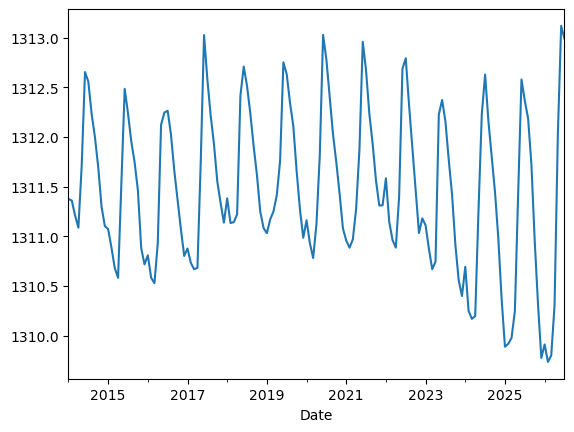

In [59]:
ct_m.plot()

<Axes: xlabel='Date'>

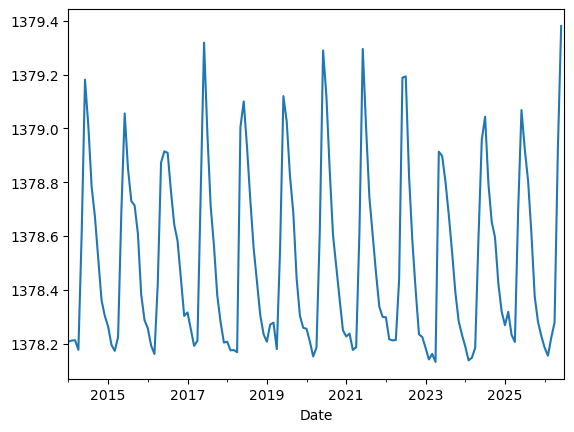

In [61]:
brab_m.plot()